In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\Export_fsq694.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 582 entries, 0 to 581
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  582 non-null    str  
 1   Message  582 non-null    str  
 2   Status   582 non-null    str  
dtypes: str(3)
memory usage: 13.8 KB


Odometer

In [3]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux['Odometer in meters']=0.0
odometer=[]
date=[]
raw=[]
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    odometer.append(int(unit_aux.iloc[i,2][96:104],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Odometer in meters']=odometer
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)

260613024156  ->  0 9303181.0 0x2525130059BB010869487064485674003C38402D000000565000000007000020000000FFFFFFFFFFFFFFFFFFFF00D5008DF48D00260613024156337320453A3B94C2F82898400000007803912569FFFFFF0000180000FFFFFF
260613064155  ->  1 9303181.0 0x2525130059BB020869487064485674003C38402D000000565000000007000020000000FFFFFFFFFFFFFFFFFFFF00D5008DF48D00260613064155337320453A3B94C2F82898400000007803902552FFFFFF0000120000FFFFFF
260613104156  ->  2 9303181.0 0x2525130059BB030869487064485674003C38402D000000565100000007000020000000FFFFFFFFFFFFFFFFFFFF00D5008DF48D00260613104156337320453A3B94C2F82898400000007803902543FFFFFF00000F0000FFFFFF
260613144156  ->  3 9303181.0 0x2525130059BB040869487064485674003C38402D000000564F00000007000020000000FFFFFFFFFFFFFFFFFFFF00D5008DF48D00260613144156337320453A3B94C2F82898400000007803922540FFFFFF0000220000FFFFFF
260613174544  ->  4 9303181.0 0x2525130059BB050869487064485674003C38402D000000524F00000007000061000000FFFFFFFFFFFFFFFFFFFF00D5008DF48D0026061317454433732045

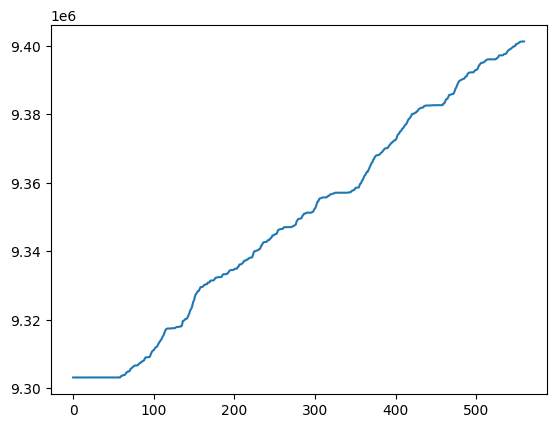

In [4]:
y_axis=[]
x_axis=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,3]))
    x_axis.append(i)
    date.append(unit.iloc[i,5])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

for i in range(0,len(odometer)):
    print(date[i],' -> ',x_axis[i],y_axis[i],raw[i])

print(odometer[len(odometer)-1]-odometer[0])
plt.plot(x_axis,y_axis)

In/outs

PS I0 I1 I2 I3 I4 I5 DI0
15 14 13 12 11 10 09 08 07 06 05 04 03 02 01 00 
          1  0  0  0  0  0  0  0  0  0  0  0  0
          1  0  0  0  0  0  0  0  0  0  0  0  0
          1  0  0  0  0  0  0  0  0  0  0  0  0

In [5]:
#TopFly Pioneer.
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]
raw_data_df=pd.DataFrame()
#cad='0x252513005900CE0869487064575128003C38402D000000644800000007000041000000FFFFFFFFFFFFFFFFFFFF00D500053670102604241257539A09BB44EE0997C2413ECB40000000F803312481FFFFFF0000190001FFFFFFx252514005908F40869487060215778003C38402D00000059500000000000002000000000000000FFFFFFFFFFFF42D50000AED51026042021294000E07E445A0D99C219C95D400000000003611173FFFFFF00001F0000FFFFFF'
#print(cad[106:118], cad[64:68], raw_data.shape[0])

for i in range(0,raw_data.shape[0]):
    long_cad=len(raw_data.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(raw_data.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][64:68]
    aux_date.append(aux_cad[i][106:118])
    #aux_raw_data.append(aux_cad[i])       
    print(aux_cad[i][64:68],bin(int(aux_cad[i][64:68],16)),aux_cad[i][106:118],aux_cad[i])

print("len aux_cad: ",len(aux_cad))

2000 0b10000000000000 260613024156 0x2525130059BB010869487064485674003C38402D000000565000000007000020000000FFFFFFFFFFFFFFFFFFFF00D5008DF48D00260613024156337320453A3B94C2F82898400000007803912569FFFFFF0000180000FFFFFF
2000 0b10000000000000 260613064155 0x2525130059BB020869487064485674003C38402D000000565000000007000020000000FFFFFFFFFFFFFFFFFFFF00D5008DF48D00260613064155337320453A3B94C2F82898400000007803902552FFFFFF0000120000FFFFFF
2000 0b10000000000000 260613104156 0x2525130059BB030869487064485674003C38402D000000565100000007000020000000FFFFFFFFFFFFFFFFFFFF00D5008DF48D00260613104156337320453A3B94C2F82898400000007803902543FFFFFF00000F0000FFFFFF
2000 0b10000000000000 260613144156 0x2525130059BB040869487064485674003C38402D000000564F00000007000020000000FFFFFFFFFFFFFFFFFFFF00D5008DF48D00260613144156337320453A3B94C2F82898400000007803922540FFFFFF0000220000FFFFFF
6100 0b110000100000000 260613174443 0x252514005906DE0869487064485674003C38402D000000564F00000007000061000000FFFFFFFFFFFFFFFFFFFF16D5008D

Satellites

Power

In [6]:
ext_bat_13=raw_data[raw_data['Status'].str.contains('0x252513')]
ext_bat_14=raw_data[raw_data['Status'].str.contains('0x252514')]
ext_bat_vol=pd.concat([ext_bat_13,ext_bat_14])
ext_bat=[]
date_bat=[]
bat_df=pd.DataFrame()

ext_bat_vol.info()

for i in range(0,ext_bat_vol.shape[0]):
    val=(float(ext_bat_vol.iloc[i,2][154:158]))/100
    date_bat.append(ext_bat_vol.iloc[i,2][106:119])
    ext_bat.append(val)
#print(ext_bat)

for i in range(0,ext_bat_vol.shape[0]):
    if ext_bat[i]<3:
        bat_df['Date']=date_bat
        bat_df['int_bat']=ext_bat

print(bat_df)

<class 'pandas.DataFrame'>
Index: 560 entries, 6 to 579
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  560 non-null    str  
 1   Message  560 non-null    str  
 2   Status   560 non-null    str  
dtypes: str(3)
memory usage: 17.5 KB
Empty DataFrame
Columns: []
Index: []


Pánico

In [7]:
aux_cad=[]
aux_date=[]
aux_raw_data=[]
#cad='0x252513005900CE0869487064575128003C38402D000000644800000007000041000000FFFFFFFFFFFFFFFFFFFF00D500053670102604241257539A09BB44EE0997C2413ECB40000000F803312481FFFFFF0000190001FFFFFFx252514005908F40869487060215778003C38402D00000059500000000000002000000000000000FFFFFFFFFFFF42D50000AED51026042021294000E07E445A0D99C219C95D400000000003611173FFFFFF00001F0000FFFFFF'
#print(cad[106:118], cad[64:68], raw_data.shape[0])

for i in range(0,raw_data.shape[0]):
    long_cad=len(raw_data.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(raw_data.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][92:94]
    #print(aux_value)#, ' -> ',aux_date[i])
    aux_date.append(aux_cad[i][106:118])
    if aux_value=='03':
        print(aux_value, ' -> ',aux_date[i])

In [8]:
#TopFly HeroX
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]
raw_data_df=pd.DataFrame()
#cad='0x252514005908F40869487060215778003C38402D00000059500000000000002000000000000000FFFFFFFFFFFF42D50000AED51026042021294000E07E445A0D99C219C95D400000000003611173FFFFFF00001F0000FFFFFF'
#print(cad[106:118])

for i in range(0,raw_data.shape[0]):
    long_cad=len(raw_data.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(raw_data.iloc[i,2])
    
for i in range(0,len(aux_cad)):    
    aux_value=aux_cad[i][64:68]
    if aux_value=='1000':
        aux_date.append(aux_cad[i][106:118])
        aux_raw_data.append(aux_cad[i])
        aux_input_number.append(2)
        print(aux_cad[i][64:68],bin(int(aux_cad[i][64:68],16)),aux_cad[i][106:118],aux_cad[i])

for i in range(0,len(aux_cad)):    
    aux_value=aux_cad[i][64:68]
    if aux_value=='2000':
        aux_date.append(aux_cad[i][106:118])
        aux_raw_data.append(aux_cad[i])
        aux_input_number.append(1)
        print(aux_cad[i][64:68],bin(int(aux_cad[i][64:68],16)),aux_cad[i][106:118],aux_cad[i])

raw_data_df['Date']=aux_date
raw_data_df['raw_data']=aux_raw_data
raw_data_df['Input']=aux_input_number

#raw_data_df.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\17n3_to_jira.csv')

2000 0b10000000000000 260613024156 0x2525130059BB010869487064485674003C38402D000000565000000007000020000000FFFFFFFFFFFFFFFFFFFF00D5008DF48D00260613024156337320453A3B94C2F82898400000007803912569FFFFFF0000180000FFFFFF
2000 0b10000000000000 260613064155 0x2525130059BB020869487064485674003C38402D000000565000000007000020000000FFFFFFFFFFFFFFFFFFFF00D5008DF48D00260613064155337320453A3B94C2F82898400000007803902552FFFFFF0000120000FFFFFF
2000 0b10000000000000 260613104156 0x2525130059BB030869487064485674003C38402D000000565100000007000020000000FFFFFFFFFFFFFFFFFFFF00D5008DF48D00260613104156337320453A3B94C2F82898400000007803902543FFFFFF00000F0000FFFFFF
2000 0b10000000000000 260613144156 0x2525130059BB040869487064485674003C38402D000000564F00000007000020000000FFFFFFFFFFFFFFFFFFFF00D5008DF48D00260613144156337320453A3B94C2F82898400000007803922540FFFFFF0000220000FFFFFF
2000 0b10000000000000 260613175454 0x252514005906DF0869487064485674003C38402D000000595000000007000020000000FFFFFFFFFFFFFFFFFFFF17D5008DF